<a href="https://colab.research.google.com/github/dee431/-Global-Earthquakes-2020-2026-A-Visual-Exploration/blob/main/%F0%9F%8C%8D%F0%9F%AB%A8Global_Earthquakes_2020%E2%80%932026_A_Visual_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cell - 1 Library Installation**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.facecolor"] = "#0d1117"
plt.rcParams["axes.facecolor"] = "#161b22"
plt.rcParams["axes.edgecolor"] = "#30363d"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["text.color"] = "white"
plt.rcParams["xtick.color"] = "#8b949e"
plt.rcParams["ytick.color"] = "#8b949e"
plt.rcParams["axes.titlecolor"] = "white"
plt.rcParams["grid.color"] = "#21262d"

# Updated path to match the file available in your environment
df = pd.read_csv("/content/global_earthquakes_2020_2026-selected-columns.csv")

df["time"] = pd.to_datetime(df["time"], format="ISO8601")
df["month"] = df["time"].dt.month

df["mag_category"] = pd.cut(df["mag"], bins=[5, 5.5, 6, 6.5, 7, 10],
    labels=["5.0-5.5", "5.5-6.0", "6.0-6.5", "6.5-7.0", "7.0+"],
    include_lowest=True)

print(f"{len(df):,} earthquakes loaded | {df['time'].min().date()} to {df['time'].max().date()}")
print("Null mag_category:", df["mag_category"].isnull().sum())

df.head()

11,808 earthquakes loaded | 2020-01-01 to 2026-07-14
Null mag_category: 0


,id,time,year,decade,latitude,longitude,depth,mag,magType,place,month,mag_category
0,us70006t13,2020-01-01 00:28:20.289000+00:00,2020,2020,-5.3245,152.5514,40.24,5.1,mb,"112 km SSE of Kokopo, Papua New Guinea",1,5.0-5.5
1,us70006t2a,2020-01-01 03:53:29.023000+00:00,2020,2020,52.6367,159.1614,58.46,5.0,mb,"56 km SE of Petropavlovsk-Kamchatsky, Russia",1,5.0-5.5
2,us70006t3c,2020-01-01 08:31:24.136000+00:00,2020,2020,-17.4280,-172.5044,10.00,5.4,mww,"207 km NE of Neiafu, Tonga",1,5.0-5.5
3,us70006t6a,2020-01-01 16:34:59.178000+00:00,2020,2020,-53.0907,9.5001,10.00,5.0,mb,southwest of Africa,1,5.0-5.5
4,us70006t6h,2020-01-01 16:51:32.285000+00:00,2020,2020,-30.2857,-71.5582,40.88,5.0,mwr,"42 km SSW of Coquimbo, Chile",1,5.0-5.5


**Quick Overview**

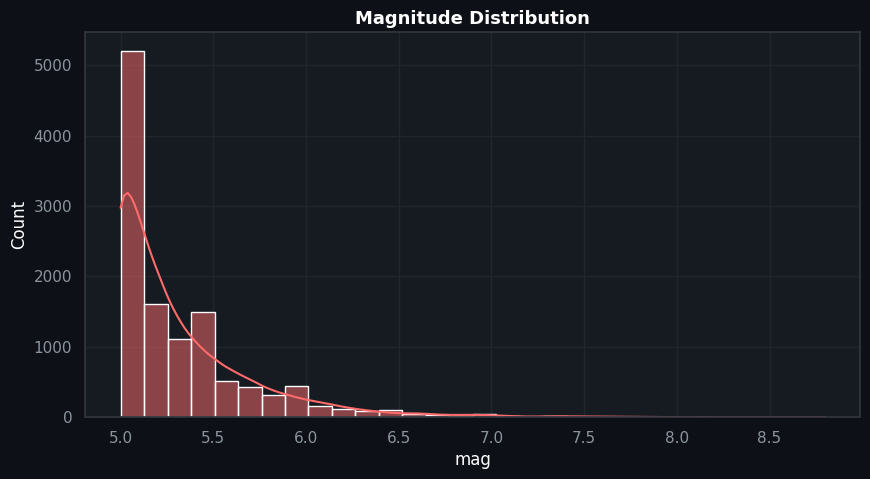

In [ ]:
# Magnitude Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["mag"], bins=30, kde=True, color="#ff6b6b")
plt.title("Magnitude Distribution", fontsize=13, fontweight="bold")
plt.show()

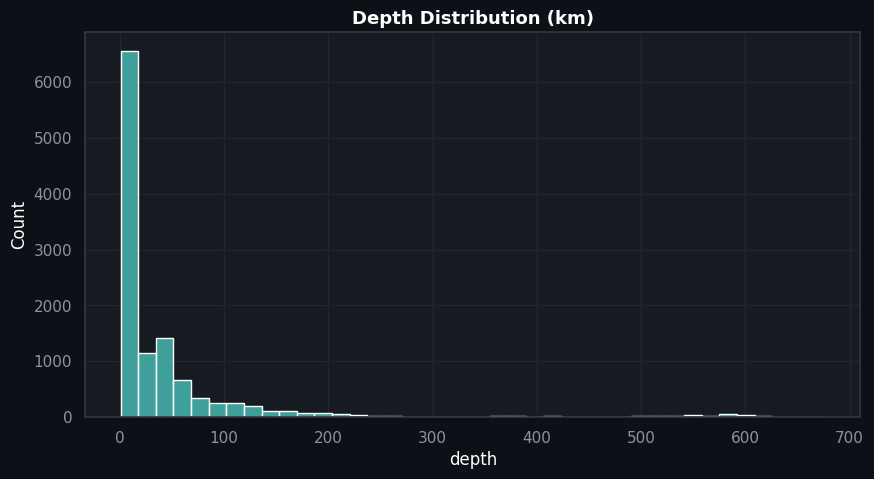

In [ ]:
# Depth Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["depth"], bins=40, color="#4ecdc4")
plt.title("Depth Distribution (km)", fontsize=13, fontweight="bold")
plt.show()

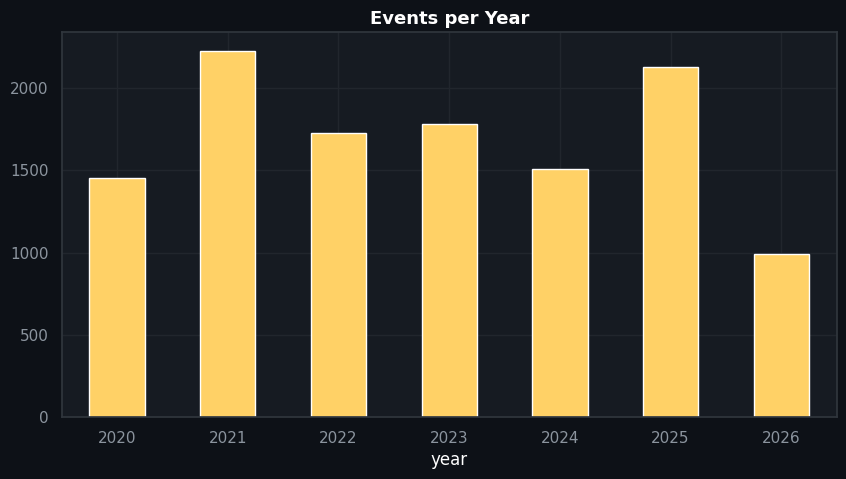

In [ ]:
# Events per Year
plt.figure(figsize=(10, 5))
df["year"].value_counts().sort_index().plot(kind="bar", color="#ffd166")
plt.title("Events per Year", fontsize=13, fontweight="bold")
plt.xticks(rotation=0)
plt.show()

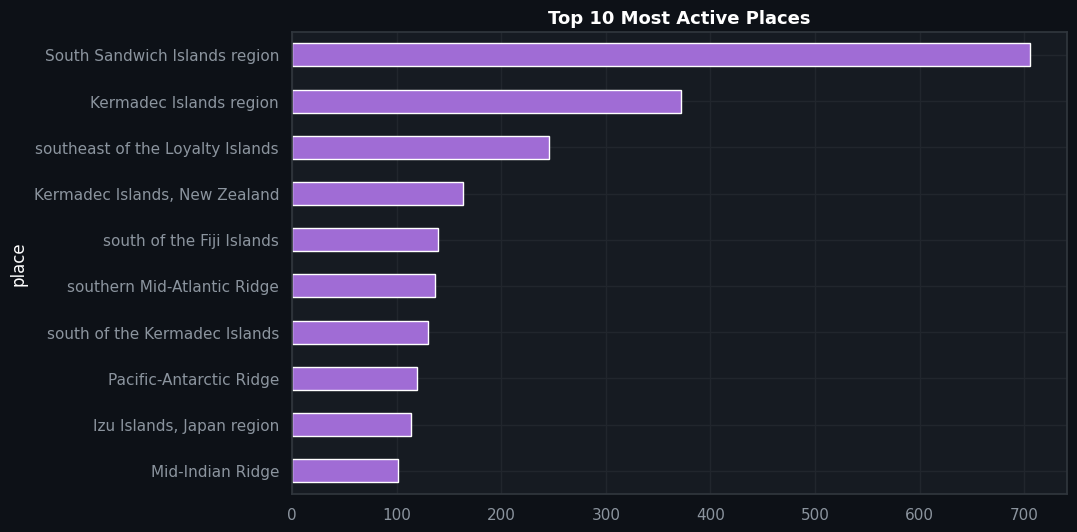

In [ ]:
# Top 10 Most Active Places
plt.figure(figsize=(10, 6))
df["place"].value_counts().head(10).plot(kind="barh", color="#a06cd5")
plt.gca().invert_yaxis()
plt.title("Top 10 Most Active Places", fontsize=13, fontweight="bold")
plt.show()

**Mapping the Ring of Fire**

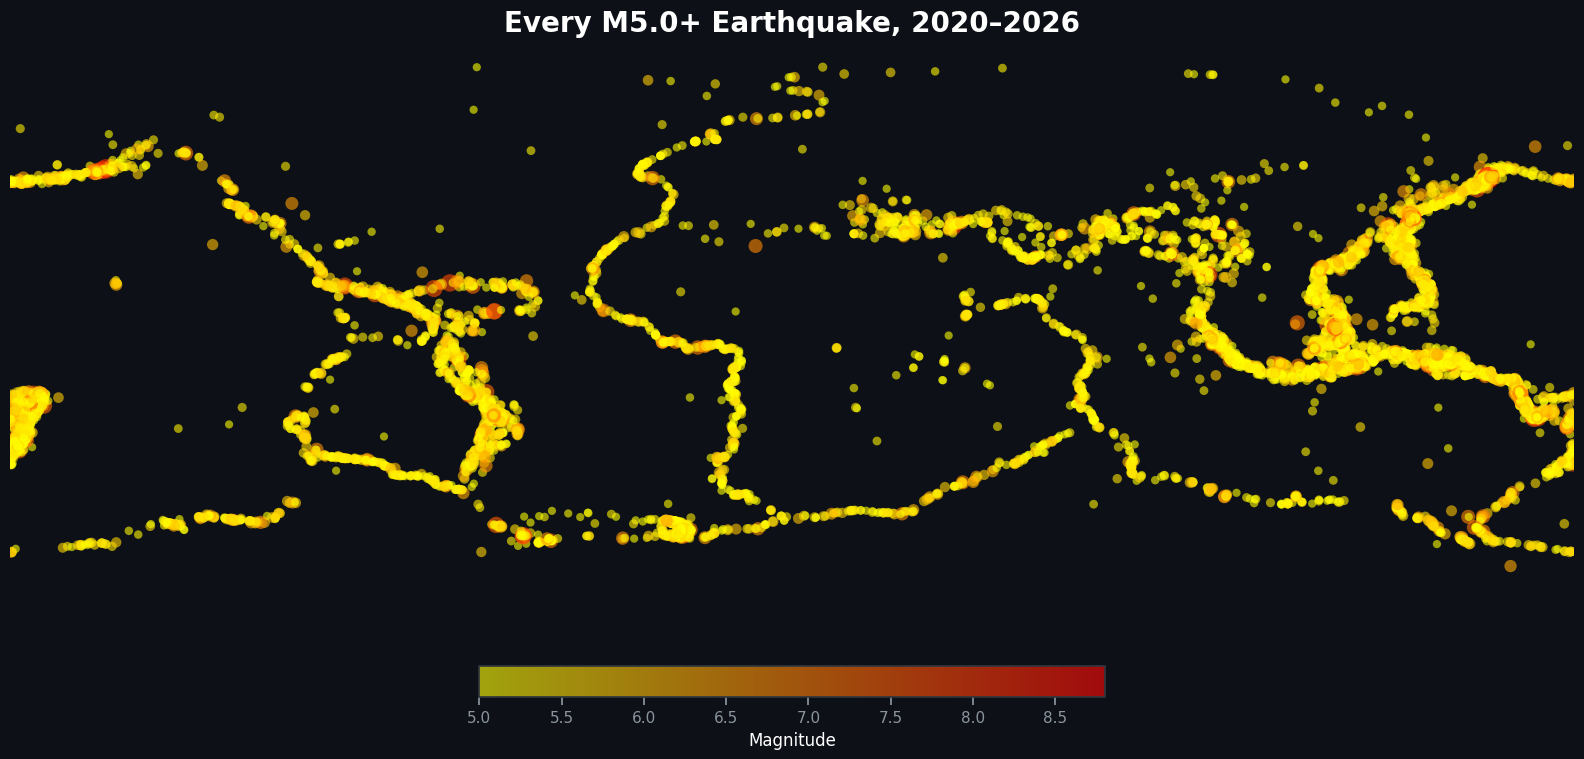

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8), facecolor="#0d1117")
ax.set_facecolor("#0d1117")

scatter = ax.scatter(
    df["longitude"], df["latitude"],
    s=df["mag"] ** 3.5 / 8,
    c=df["mag"], cmap="autumn_r", alpha=0.6, edgecolors="none"
)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks([]); ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(scatter, ax=ax, orientation="horizontal", pad=0.05, shrink=0.4)
cbar.set_label("Magnitude", color="white")

ax.set_title("Every M5.0+ Earthquake, 2020–2026", fontsize=20, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()


**Is seismic activity trending anywhere?**

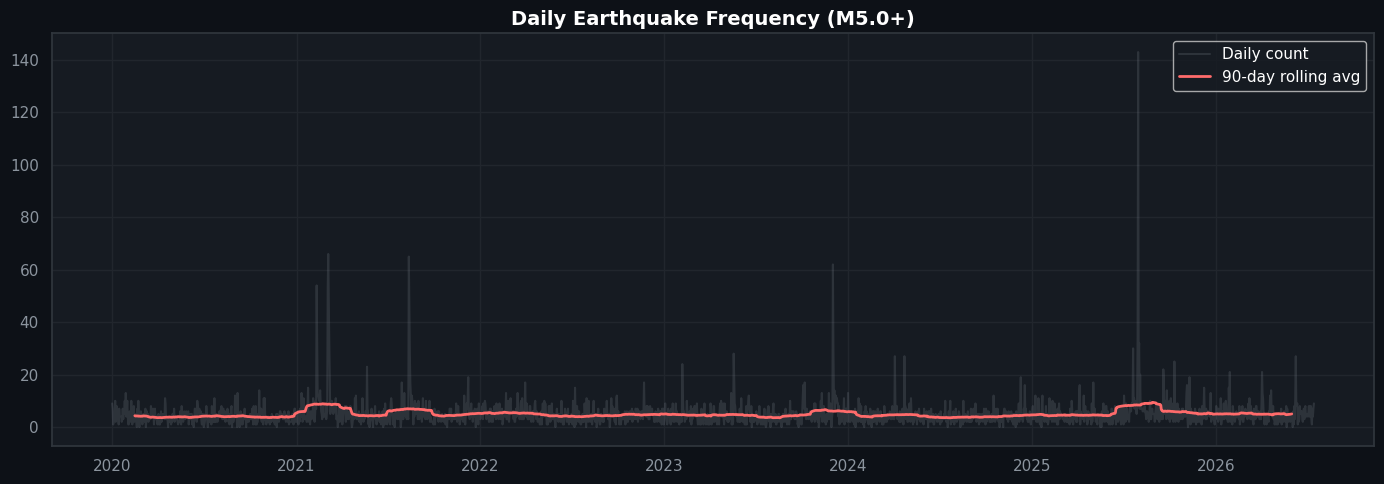

In [ ]:
daily = df.set_index("time").resample("D").size()
rolling = daily.rolling(90, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index, daily.values, alpha=0.2, color="#8b949e", label="Daily count")
ax.plot(rolling.index, rolling.values, color="#ff6b6b", linewidth=2, label="90-day rolling avg")
ax.set_title("Daily Earthquake Frequency (M5.0+)", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

**Does time of year matter?**

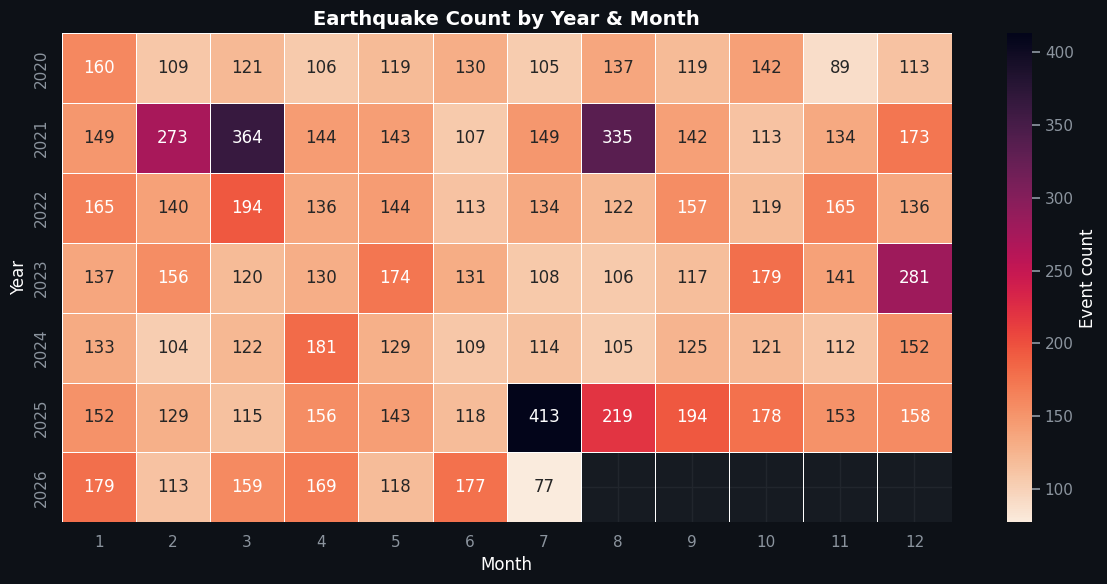

In [ ]:
pivot = df.pivot_table(index="year", columns="month", values="id", aggfunc="count")

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="rocket_r", annot=True, fmt=".0f", linewidths=0.5,
            cbar_kws={"label": "Event count"})
plt.title("Earthquake Count by Year & Month", fontsize=14, fontweight="bold")
plt.xlabel("Month"); plt.ylabel("Year")
plt.tight_layout()
plt.show()

**Depth vs. Magnitude**

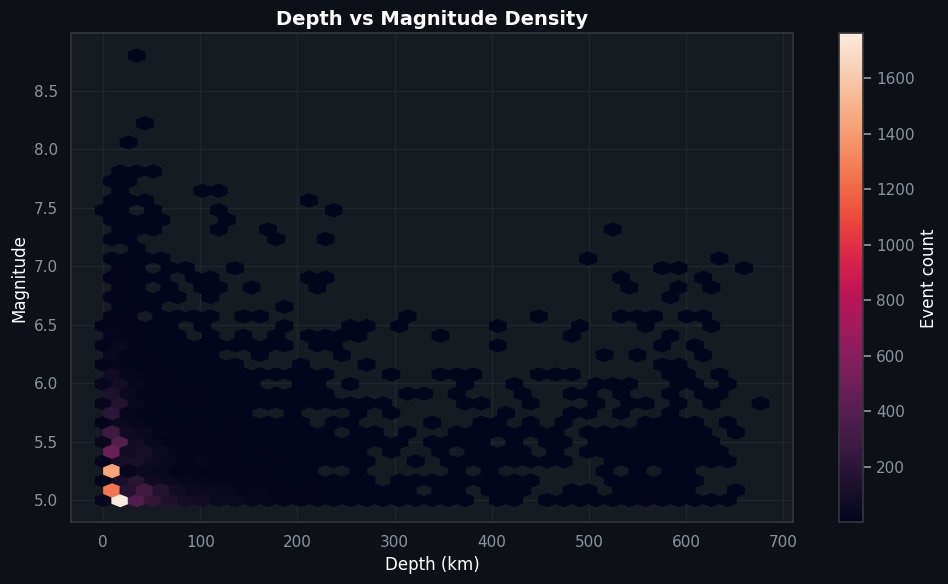

Correlation (depth, mag): 0.095


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
hb = ax.hexbin(df["depth"], df["mag"], gridsize=40, cmap="rocket", mincnt=1)
ax.set_xlabel("Depth (km)"); ax.set_ylabel("Magnitude")
ax.set_title("Depth vs Magnitude Density", fontsize=14, fontweight="bold")
plt.colorbar(hb, label="Event count")
plt.tight_layout()
plt.show()

print("Correlation (depth, mag):", round(df["depth"].corr(df["mag"]), 3))

**How do the numeric fields relate to each other?**

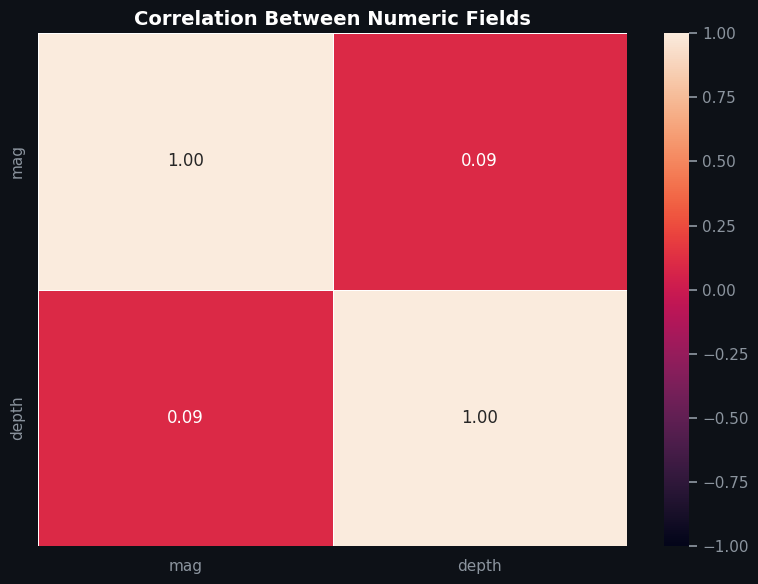

In [ ]:
numeric_cols = ["mag", "depth"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Between Numeric Fields", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()